In [3]:
from typing import TypedDict, List, Dict, Any, Literal
from pydantic import BaseModel, Field
import time

from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader,PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import os



In [4]:

load_dotenv()

OPENROUTER_API_KEY=os.getenv("OPENROUTER_API_KEY")
os.environ["OPENROUTER_API_KEY"]=OPENROUTER_API_KEY

model= ChatOpenAI( base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    model= "nvidia/nemotron-3-nano-30b-a3b:free"
)
model.invoke("hello")

AIMessage(content='Hello! 👋 How can I assist you today? If you have any questions or need help with anything, just let me know!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 17, 'total_tokens': 67, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 26, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-nano-30b-a3b:free', 'system_fingerprint': None, 'id': 'gen-1772022476-z6Wns1GQLrKXLeghumnV', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c94c4-e71e-7471-8e6a-2d856148a74b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 50, 'total_tokens': 6

In [5]:
dir_path = "./documents"

loader=PyPDFDirectoryLoader(
    path= dir_path,
    glob= "**/*.pdf",
)

docs= loader.load()

In [6]:
chunks = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200).split_documents(docs)
chunks[:3]

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'documents\\Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave: A

In [7]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': False})

vectorstore = FAISS.from_documents(documents=chunks,
                                embedding=embeddings)

retriever = vectorstore.as_retriever(search_kwargs={'k':3})

C:\Users\vaibh\AppData\Local\Temp\ipykernel_11072\1842760762.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


In [8]:
class State(TypedDict):
    question :str
    need_retrieval : bool
    docs : List[Document]
    relevent_docs : List[Document]
    context : str #new
    answer :str
    

In [9]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

# IMPORTANT: no `.content` for structured output
should_retrieve_llm = model.with_structured_output(RetrieveDecision,include_raw= False)

def decide_retrieval(state : State):
    decision : RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
        
    )
    
    return {'need_retrieval': decision.should_retrieve}

In [10]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state:State):
    out = model.invoke(
        direct_generation_prompt.format_messages(question=state['question'])
    )
    return {'answer':out.content}

In [11]:
def retrieve(state:State):
    return {'docs': retriever.invoke(state['question'])}


In [12]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevent_llm = model.with_structured_output(RelevanceDecision)

def is_relevant(state:State):
    relevance_docs : List[Document] =[]
    
    for doc in state['docs']:
        decision :RelevanceDecision = relevent_llm.invoke(
            is_relevant_prompt.format_messages(
                question= state['question'],
                document = doc.page_content
                
            )
        )
        
        if decision.is_relevant:
            relevance_docs.append(doc)
            
    return {'relevent_docs':relevance_docs}
    

In [13]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
    
)

def generate_from_context(state:State):
    
    context = "\n\n---\n\n".join([doc.page_content for doc in state.get('relevent_docs',[])]).strip()
    
    if not context:
        return {'answer': 'No relevant doc found', 'context':''}
    
    out = model.invoke(
        rag_generation_prompt.format_messages(
            question=state['question'],
            context = context
        )
    )
    return {'answer': out.content, 'context': context}

In [14]:
def no_docs_relevant(state:State):
    return {'answer': 'No relevant doc found', 'context':''}

In [15]:
def route_after_decide(state:State):
    if state['need_retrieval']:
        return 'retrieve'
    return "generate_direct"

In [16]:
def route_after_relevance(state:State)-> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get('relevent_docs') and len(state['relevent_docs'])>0:
        return 'generate_from_context'
    
    return 'no_docs_relevant'

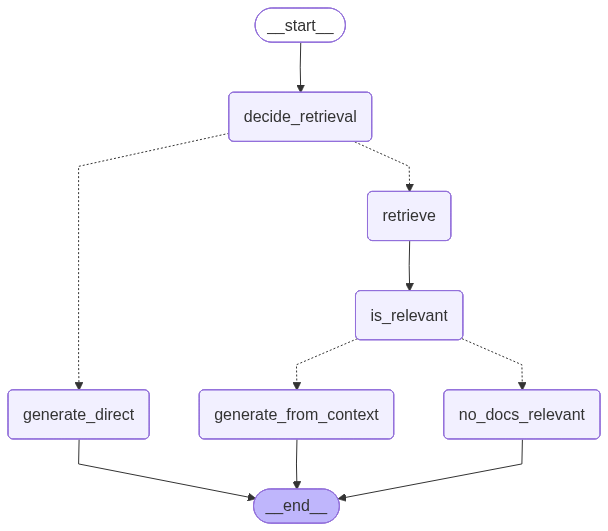

In [17]:
g = StateGraph(State)
g.add_node('decide_retrieval',decide_retrieval)
g.add_node('generate_direct',generate_direct)
g.add_node('retrieve',retrieve)
g.add_node('is_relevant',is_relevant)
g.add_node('generate_from_context',generate_from_context)
g.add_node('no_docs_relevant',no_docs_relevant)

g.add_edge(START,'decide_retrieval')
g.add_conditional_edges('decide_retrieval',route_after_decide,
                        {'generate_direct':"generate_direct",
                        'retrieve':"retrieve"}
                        )
g.add_edge('generate_direct',END)
g.add_edge('retrieve',"is_relevant")
g.add_conditional_edges('is_relevant',route_after_relevance,
                        {
                            'generate_from_context':'generate_from_context',
                            'no_docs_relevant': 'no_docs_relevant'
                        })
g.add_edge('generate_from_context',END)
g.add_edge('no_docs_relevant',END)
# g.add_edge('is_relevant',END)

app=g.compile()
app

In [18]:
result = app.invoke(
    {
        "question": "What is the refund policy of NexaAI",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

d:\Vaibhav_PC\GenerativeAI\GI\Advance_RAG\Campus_RAG\Self_RAG\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RetrieveDecision(should_retrieve=True), input_type=RetrieveDecision])
  return self.__pydantic_serializer__.to_python(
d:\Vaibhav_PC\GenerativeAI\GI\Advance_RAG\Campus_RAG\Self_RAG\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RelevanceDecision(is_relevant=False), input_type=RelevanceDecision])
  return self.__pydantic_serializer__.to_python(


No relevant doc found


In [19]:
result = app.invoke(
    {
        "question": "Who is the CEO of NexaAI",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

d:\Vaibhav_PC\GenerativeAI\GI\Advance_RAG\Campus_RAG\Self_RAG\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RelevanceDecision(is_relevant=True), input_type=RelevanceDecision])
  return self.__pydantic_serializer__.to_python(


The CEO of NexaAI is **Aarav Mehta**, who is also the Founder.


In [22]:
result['context']

'Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems & AI platforms)\n\x7f\nKunal Sharma – Head of Product\n\x7f\nNeha Verma – Head of Operations & HR\n\x7f\nSiddharth Rao – Head of Sales & Partnerships'

In [21]:
for doc in result['relevent_docs']:
    print(doc.page_content)
    print('**'*50)

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships
****************************************************************************************************
